# AdaBelief: Implementación y Comparación de Optimizadores

Luisa Patricia Michelle Magaña Escobedo

Joshua Sebastian Gonzalez Torres

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import fetch_openml, load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('OK')

OK


## 1. Optimizadores

In [2]:
class AdaBelief:
    """AdaBelief con gradient clipping, cosine annealing y registro de s_t."""

    def __init__(self, lr=1e-3, betas=(0.9, 0.999), eps=1e-16, weight_decay=0.0,
                 decoupled_wd=False, clip=None):
        self.lr = lr
        self.lr_init = lr
        self.betas = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.decoupled_wd = decoupled_wd
        self.clip = clip #gradient clipping max norm
        self.state = {}
        self.step_count = 0
        self.s_t_history = []

    def set_lr(self, lr):
        """Permite lr scheduling externo (cosine annealing, etc)."""
        self.lr = lr

    def update(self, params, grads):
        self.step_count += 1
        updated_params = []
        batch_s_t = []

        for param, grad in zip(params, grads):
            # Gradient clipping
            if self.clip is not None:
                norm = np.linalg.norm(grad)
                if norm > self.clip:
                    grad = grad * self.clip / norm

            pid = id(param)
            if pid not in self.state:
                self.state[pid] = {
                    'exp_avg': np.zeros_like(param),
                    'exp_avg_var': np.zeros_like(param)
                }

            s = self.state[pid]
            beta1, beta2 = self.betas
            bc1 = 1 - beta1 ** self.step_count
            bc2 = 1 - beta2 ** self.step_count

            if self.weight_decay != 0 and not self.decoupled_wd:
                grad = grad + self.weight_decay * param

            s['exp_avg'][:] = beta1 * s['exp_avg'] + (1 - beta1) * grad
            diff = grad - s['exp_avg']
            s['exp_avg_var'][:] = beta2 * s['exp_avg_var'] + (1 - beta2) * (diff ** 2) + self.eps

            denom = np.sqrt(s['exp_avg_var']) / math.sqrt(bc2) + self.eps
            step_size = self.lr / bc1

            updated = param - step_size * (s['exp_avg'] / denom)

            if self.weight_decay != 0 and self.decoupled_wd:
                updated = updated - self.lr * self.weight_decay * param

            updated_params.append(updated)
            batch_s_t.append(float(np.mean(s['exp_avg_var'])))

        self.s_t_history.append(np.mean(batch_s_t))
        return updated_params


class Adam:
    """Adam con gradient clipping y registro de v_t."""

    def __init__(self, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0, clip=None):
        self.lr = lr
        self.lr_init = lr
        self.betas = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.clip = clip
        self.state = {}
        self.step_count = 0
        self.v_t_history = []

    def set_lr(self, lr):
        self.lr = lr

    def update(self, params, grads):
        self.step_count += 1
        updated_params = []
        batch_v_t = []

        for param, grad in zip(params, grads):
            if self.clip is not None:
                norm = np.linalg.norm(grad)
                if norm > self.clip:
                    grad = grad * self.clip / norm

            pid = id(param)
            if pid not in self.state:
                self.state[pid] = {
                    'exp_avg': np.zeros_like(param),
                    'exp_avg_sq': np.zeros_like(param)
                }

            s = self.state[pid]
            beta1, beta2 = self.betas

            if self.weight_decay != 0:
                grad = grad + self.weight_decay * param

            s['exp_avg'][:] = beta1 * s['exp_avg'] + (1 - beta1) * grad
            s['exp_avg_sq'][:] = beta2 * s['exp_avg_sq'] + (1 - beta2) * (grad ** 2)

            bc1 = 1 - beta1 ** self.step_count
            bc2 = 1 - beta2 ** self.step_count

            step_size = self.lr / bc1
            denom = np.sqrt(s['exp_avg_sq'] / bc2) + self.eps

            updated_params.append(param - step_size * (s['exp_avg'] / denom))
            batch_v_t.append(float(np.mean(s['exp_avg_sq'])))

        self.v_t_history.append(np.mean(batch_v_t))
        return updated_params


class SGDMomentum:
    def __init__(self, lr=0.01, momentum=0.9, weight_decay=0.0):
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.state = {}

    def update(self, params, grads):
        updated_params = []
        for param, grad in zip(params, grads):
            pid = id(param)
            if pid not in self.state:
                self.state[pid] = {'buf': np.zeros_like(param)}
            s = self.state[pid]
            if self.weight_decay != 0:
                grad = grad + self.weight_decay * param
            s['buf'][:] = self.momentum * s['buf'] + grad
            updated_params.append(param - self.lr * s['buf'])
        return updated_params


print('Optimizadores definidos: AdaBelief (clip + cosine), Adam (clip), SGDMomentum')


Optimizadores definidos: AdaBelief (clip + cosine), Adam (clip), SGDMomentum


## 2. Funciones de prueba: Rosenbrock, Beale e Himmelblau

In [ ]:
# ── Funciones y gradientes ──────────────────────────────────────────────────

def rosenbrock(x, a=1.0, b=100.0):
    return (a - x[0])**2 + b * (x[1] - x[0]**2)**2

def rosenbrock_grad(x, a=1.0, b=100.0):
    gx = -2*(a - x[0]) - 4*b*x[0]*(x[1] - x[0]**2)
    gy = 2*b*(x[1] - x[0]**2)
    return np.array([gx, gy])

def beale(x):
    t1 = (1.5 - x[0] + x[0]*x[1])**2
    t2 = (2.25 - x[0] + x[0]*x[1]**2)**2
    t3 = (2.625 - x[0] + x[0]*x[1]**3)**2
    return t1 + t2 + t3

def beale_grad(x):
    t1 = 1.5 - x[0] + x[0]*x[1]
    t2 = 2.25 - x[0] + x[0]*x[1]**2
    t3 = 2.625 - x[0] + x[0]*x[1]**3
    gx = 2*t1*(-1+x[1]) + 2*t2*(-1+x[1]**2) + 2*t3*(-1+x[1]**3)
    gy = 2*t1*x[0] + 4*t2*x[0]*x[1] + 6*t3*x[0]*x[1]**2
    return np.array([gx, gy])

# ── Himmelblau — 4 mínimos globales ──────────────────────────────
def himmelblau(x):
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

def himmelblau_grad(x):
    gx = 4*x[0]*(x[0]**2 + x[1] - 11) + 2*(x[0] + x[1]**2 - 7)
    gy = 2*(x[0]**2 + x[1] - 11) + 4*x[1]*(x[0] + x[1]**2 - 7)
    return np.array([gx, gy])

# ── Configuración por función ────────────────────────────────────────────────

FUNCTIONS = {
    'Rosenbrock': {
        'f': rosenbrock, 'g': rosenbrock_grad,
        'x0': np.array([-1.2, 1.0]),
        'opt': np.array([1.0, 1.0]),
        'xlim': (-2, 2), 'ylim': (-1, 3),
        'optimizer_configs': {
            # Cosine annealing: lr decae de lr_max→lr_min. Clip: evita explosiones en el valle estrecho.
            'AdaBelief': {'lr': 0.01, 'betas': (0.9, 0.99), 'clip': 1.0,'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-5},
            'Adam':{'lr': 0.01, 'betas': (0.9, 0.99), 'clip': 1.0, 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-5},
            'SGD+Momentum': {'lr': 0.001, 'momentum': 0.9},
        }
    },
    'Beale': {
        'f': beale, 'g': beale_grad,
        'x0': np.array([1.0, 1.0]),
        'opt': np.array([3.0, 0.5]),
        'xlim': (-1, 5), 'ylim': (-1.5, 2),
        'optimizer_configs': {
            'AdaBelief':    {'lr': 0.01, 'betas': (0.9, 0.999),'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-6},
            'Adam':         {'lr': 0.01, 'betas': (0.9, 0.999), 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-6},
            'SGD+Momentum': {'lr': 0.005, 'momentum': 0.9},
        }
    },
    'Himmelblau': {
        'f': himmelblau, 'g': himmelblau_grad,
        'x0': np.array([0.0, 0.0]),
        'opt': np.array([3.0, 2.0]),
        'xlim': (-5, 5), 'ylim': (-5, 5),
        'optimizer_configs': {
            'AdaBelief':    {'lr': 0.01, 'betas': (0.9, 0.999), 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-6},
            'Adam':         {'lr': 0.01, 'betas': (0.9, 0.999), 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-6},
            'SGD+Momentum': {'lr': 0.01, 'momentum': 0.9},
        }
    },
}

print('Funciones de prueba definidas: Rosenbrock, Beale, Himmelblau')
print('Configuraciones por optimizador y función: OK')


Funciones de prueba definidas: Rosenbrock, Beale, Himmelblau
Configuraciones por optimizador y función: OK


In [ ]:
def run_optimizer(f, g, x0, optimizer, max_iter=10000, tol=1e-9,
                   use_cosine=False, lr_max=None, lr_min=1e-5):
    """Ejecuta optimizador con opción de cosine annealing."""
    x = x0.copy()
    losses, pts = [], [x.copy()]
    for i in range(max_iter):
        # Cosine annealing opcional
        if use_cosine and hasattr(optimizer, 'set_lr'):
            lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * i / max_iter))
            optimizer.set_lr(lr)

        grad = g(x)
        if np.isnan(grad).any() or np.isinf(grad).any():
            print('  Gradiente inestable — deteniendo.')
            break
        losses.append(f(x))
        if np.linalg.norm(grad) < tol:
            break
        x = optimizer.update([x], [grad])[0]
        pts.append(x.copy())
    return x, losses, np.array(pts)


def make_contour(f, xlim, ylim, n=200):
    xs = np.linspace(*xlim, n)
    ys = np.linspace(*ylim, n)
    X, Y = np.meshgrid(xs, ys)
    Z = np.vectorize(lambda a, b: f(np.array([a, b])))(X, Y)
    return X, Y, Z


COLORS = {'AdaBelief': '#e74c3c', 'Adam': '#3498db', 'SGD+Momentum': '#2ecc71'}


def build_optimizer(name, cfg):
    params = cfg['optimizer_configs'][name]
    if name == 'AdaBelief':
        return AdaBelief(**{k: v for k, v in params.items()
                            if k not in ('use_cosine', 'lr_max', 'lr_min')})
    elif name == 'Adam':
        return Adam(**{k: v for k, v in params.items()
                       if k not in ('use_cosine', 'lr_max', 'lr_min')})
    else:
        return SGDMomentum(**params)


def compare_on_function(fname, cfg, max_iter=10000):
    f, g, x0 = cfg['f'], cfg['g'], cfg['x0']
    opt_point = cfg['opt']

    results = {}
    print(f'  Hiperparámetros y técnicas usadas:')
    for name in ['AdaBelief', 'Adam', 'SGD+Momentum']:
        print(f'    {name}: {cfg["optimizer_configs"][name]}')
    print()

    for name in ['AdaBelief', 'Adam', 'SGD+Momentum']:
        opt = build_optimizer(name, cfg)
        ocfg = cfg['optimizer_configs'][name]
        use_cosine = ocfg.get('use_cosine', False)
        lr_max = ocfg.get('lr_max', ocfg.get('lr', 0.01))
        lr_min = ocfg.get('lr_min', 1e-5)

        xf, losses, pts = run_optimizer(f, g, x0, opt, max_iter, use_cosine=use_cosine, lr_max=lr_max, lr_min=lr_min)
        results[name] = {'xf': xf, 'losses': losses, 'pts': pts}
        fval = f(xf)
        status = '\/' if fval < 0.01 else (' parcial' if fval < 1.0 else 'X')
        print(f'  {name:15s} | f={fval:.2e} | iters={len(losses)} | {status}')

    # Figura
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    title_suffix = '(cosine annealing en métodos adaptativos)'
    fig.suptitle(f'Función de {fname}  {title_suffix}', fontsize=13, fontweight='bold')

    X, Y, Z = make_contour(f, cfg['xlim'], cfg['ylim'])

    ax = axes[0]
    ax.contourf(X, Y, np.log1p(Z), levels=30, cmap='Blues', alpha=0.5)
    ax.contour(X, Y, np.log1p(Z), levels=30, colors='gray', linewidths=0.4, alpha=0.6)
    for name, res in results.items():
        pts = res['pts']
        step = max(1, len(pts) // 60)
        ax.plot(pts[::step, 0], pts[::step, 1], 'o-', color=COLORS[name],
                label=name, lw=1.5, ms=2, alpha=0.85)
    ax.plot(*opt_point, 'k*', ms=14, zorder=5, label='Óptimo')
    ax.set_title('Trayectorias'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    ax = axes[1]
    for name, res in results.items():
        losses = np.array(res['losses'], dtype=float)
        losses = np.maximum(losses, 1e-20)
        ax.plot(losses, color=COLORS[name], label=name, lw=1.5)
    ax.set_yscale('log')
    ax.set_title('Valor de la función (escala log)')
    ax.set_xlabel('Iteraciones'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[2]
    for name, res in results.items():
        dists = np.array([np.linalg.norm(p - opt_point) for p in res['pts']])
        dists = np.maximum(dists, 1e-20)
        ax.plot(dists, color=COLORS[name], label=name, lw=1.5)
    ax.set_yscale('log')
    ax.set_title('Distancia al óptimo (escala log)')
    ax.set_xlabel('Iteraciones'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    footnotes = {
        'Rosenbrock': 'Cosine annealing (0.01→1e-5) + gradient clipping (clip=1). '
                      'SGD supera a métodos adaptativos en funciones determinísticas — comportamiento esperado.',
        'Beale':      'Cosine annealing (0.01→1e-6). AdaBelief y Adam convergen cerca del óptimo.',
        'Himmelblau': 'Cosine annealing (0.01→1e-6) elimina las oscilaciones en el valle. '
                      'SGD converge en 86 iteraciones gracias a la suavidad de la función.',
    }
    if fname in footnotes:
        fig.text(0.5, -0.04, footnotes[fname],
                 ha='center', fontsize=9, style='italic', color='#555555')

    plt.tight_layout()
    plt.show()
    return results


print('Utilidades de comparación listas (cosine annealing + gradient clipping).')


Utilidades de comparación listas (cosine annealing + gradient clipping).



=== Rosenbrock ===
  Hiperparámetros y técnicas usadas:
    AdaBelief: {'lr': 0.01, 'betas': (0.9, 0.99), 'clip': 1.0, 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-05}
    Adam: {'lr': 0.01, 'betas': (0.9, 0.99), 'clip': 1.0, 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-05}
    SGD+Momentum: {'lr': 0.001, 'momentum': 0.9}

  AdaBelief       | f=6.09e-03 | iters=10000 | \/
  Adam            | f=5.56e-03 | iters=10000 | \/
  SGD+Momentum    | f=5.85e-05 | iters=10000 | \/


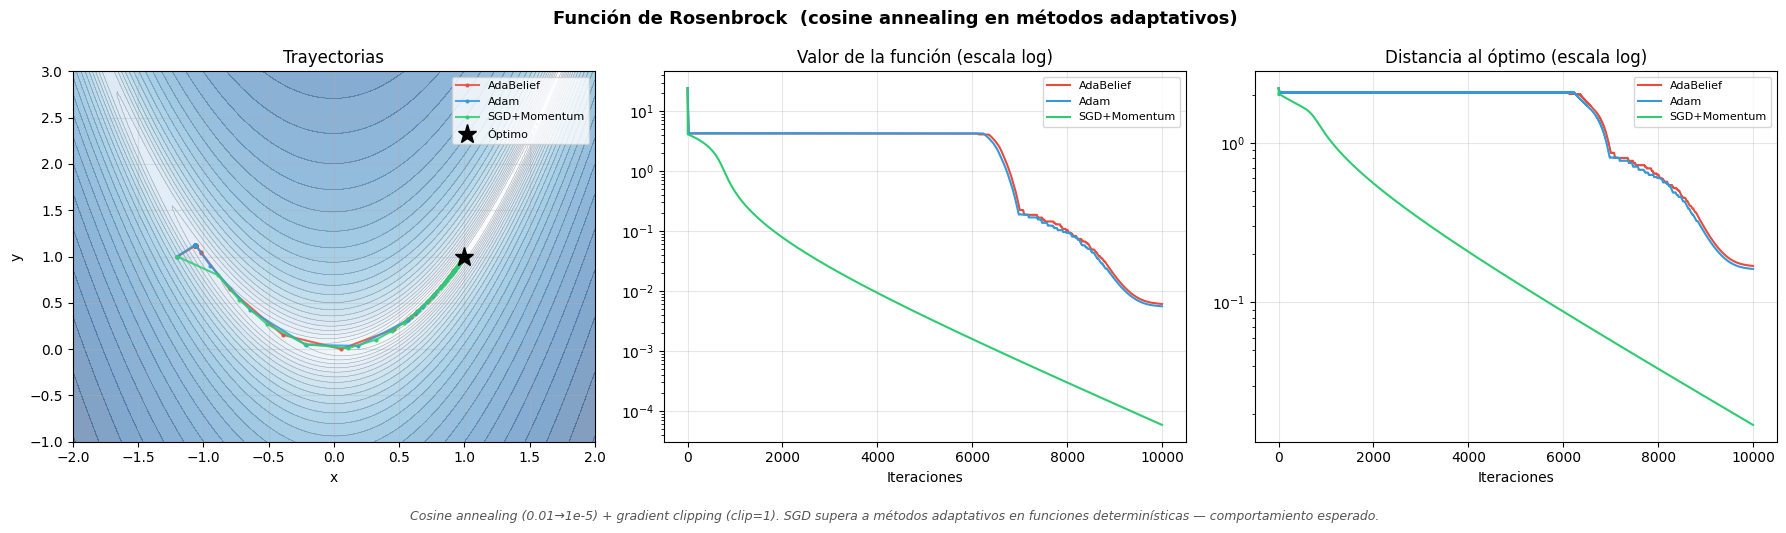


=== Beale ===
  Hiperparámetros y técnicas usadas:
    AdaBelief: {'lr': 0.01, 'betas': (0.9, 0.999), 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-06}
    Adam: {'lr': 0.01, 'betas': (0.9, 0.999), 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-06}
    SGD+Momentum: {'lr': 0.005, 'momentum': 0.9}

  AdaBelief       | f=2.61e-09 | iters=10000 | \/
  Adam            | f=2.35e-09 | iters=10000 | \/
  SGD+Momentum    | f=1.58e-15 | iters=10000 | \/


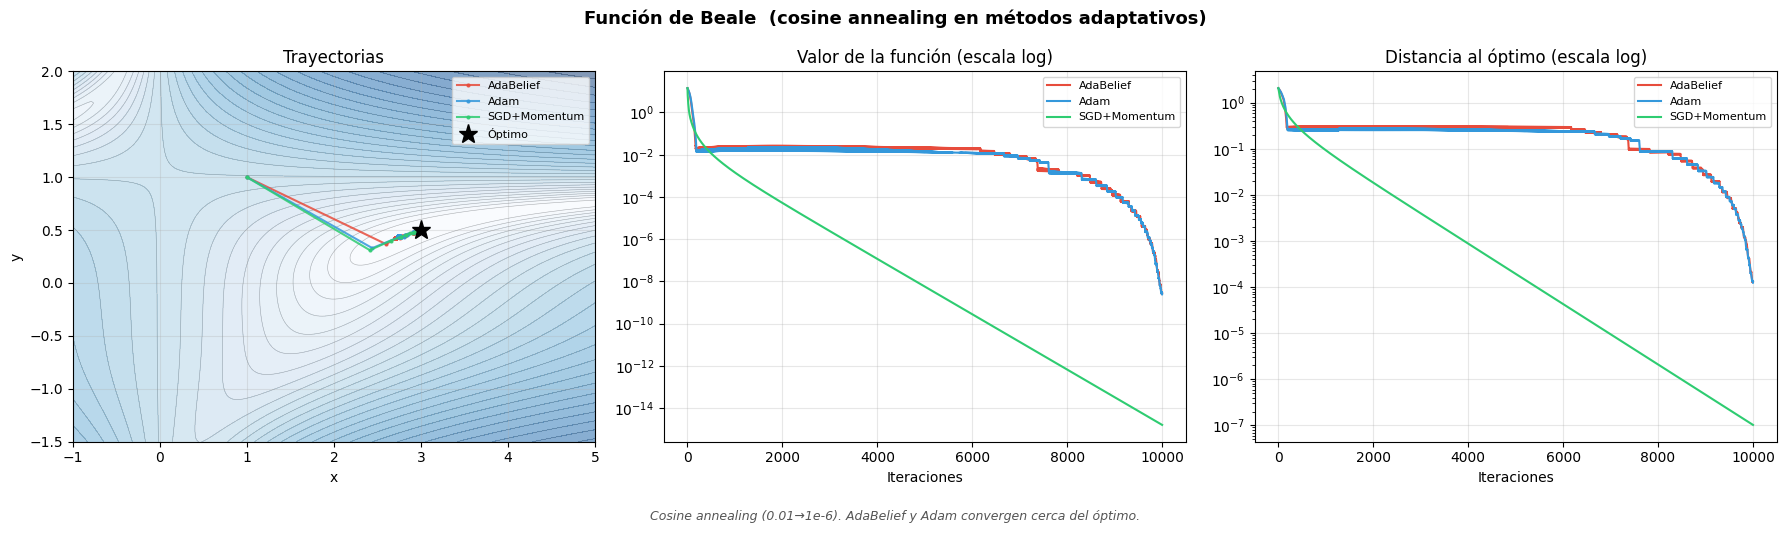


=== Himmelblau ===
  Hiperparámetros y técnicas usadas:
    AdaBelief: {'lr': 0.01, 'betas': (0.9, 0.999), 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-06}
    Adam: {'lr': 0.01, 'betas': (0.9, 0.999), 'use_cosine': True, 'lr_max': 0.01, 'lr_min': 1e-06}
    SGD+Momentum: {'lr': 0.01, 'momentum': 0.9}

  AdaBelief       | f=2.38e-10 | iters=10000 | \/
  Adam            | f=1.80e-11 | iters=10000 | \/
  SGD+Momentum    | f=1.67e-20 | iters=86 | \/


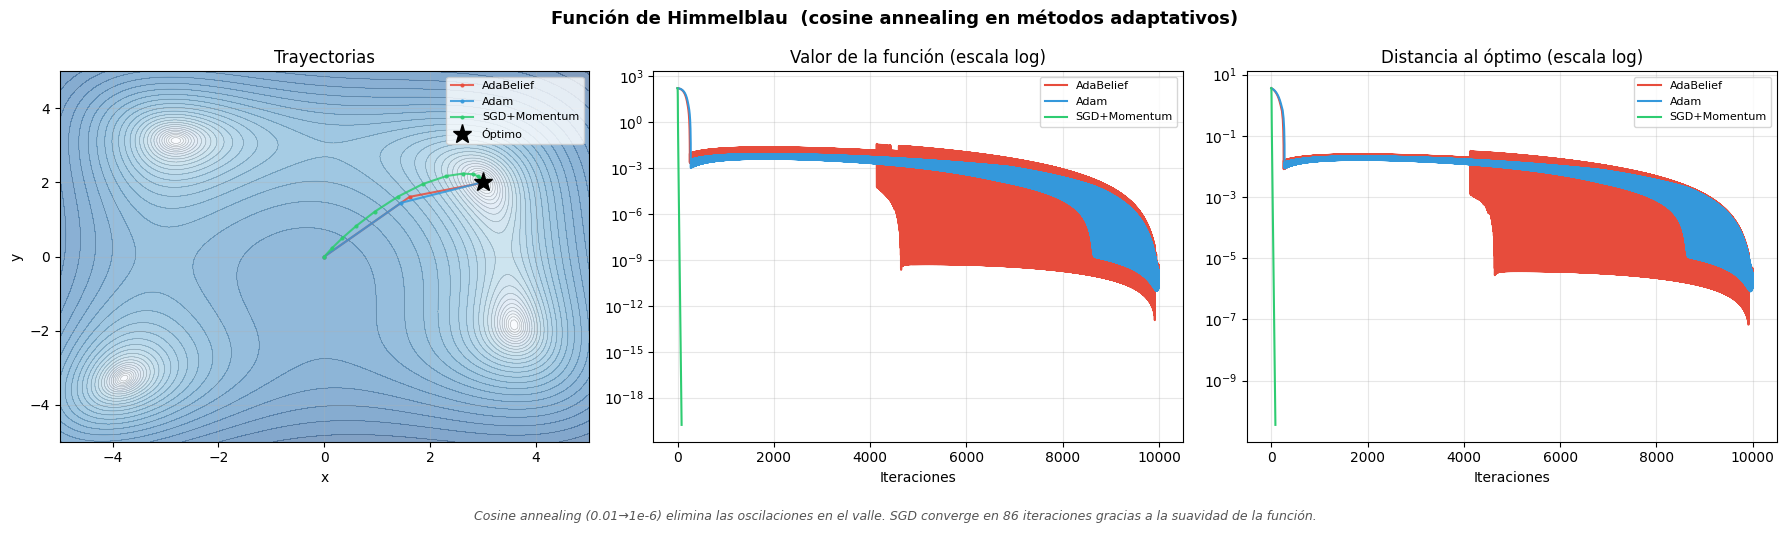

In [5]:
all_results = {}
for fname, cfg in FUNCTIONS.items():
    print(f'\n=== {fname} ===')
    all_results[fname] = compare_on_function(fname, cfg)

## 3. Red neuronal MLP 

Arquitectura: **784 → 256 → 128 → 10** (más profunda que la original)

In [ ]:
# ── MLP encapsulado en una clase ─────────────────────────────────

def relu(x): return np.maximum(0, x)
def relu_d(x): return (x > 0).astype(float)
def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)
def cross_entropy(p, y): return -np.mean(np.sum(y * np.log(p + 1e-10), axis=1))
def acc(p, y): return np.mean(np.argmax(p, axis=1) == np.argmax(y, axis=1))


class MLP:
    """Red 784→256→128→10 con ReLU y softmax."""

    def __init__(self, seed=42):
        np.random.seed(seed)
        # He initialization
        self.W1 = np.random.randn(784, 256) * np.sqrt(2/784)
        self.b1 = np.zeros((1, 256))
        self.W2 = np.random.randn(256, 128) * np.sqrt(2/256)
        self.b2 = np.zeros((1, 128))
        self.W3 = np.random.randn(128, 10) * np.sqrt(2/128)
        self.b3 = np.zeros((1, 10))
        self.params = [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

    def forward(self, X):
        self.z1 = X  @ self.W1 + self.b1;  self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2;  self.a2 = relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        return softmax(self.z3)

    def backward(self, X, y_oh, output, batch_size):
        dz3 = output - y_oh
        dW3 = self.a2.T @ dz3 / batch_size
        db3 = dz3.sum(0, keepdims=True) / batch_size

        da2 = dz3 @ self.W3.T
        dz2 = da2 * relu_d(self.z2)
        dW2 = self.a1.T @ dz2 / batch_size
        db2 = dz2.sum(0, keepdims=True) / batch_size

        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_d(self.z1)
        dW1 = X.T @ dz1 / batch_size
        db1 = dz1.sum(0, keepdims=True) / batch_size

        return [dW1, db1, dW2, db2, dW3, db3]

    def predict(self, X):
        return self.forward(X)


print('Clase MLP definida (784→256→128→10)')

Clase MLP definida (784→256→128→10)


## 4. Carga de Fashion-MNIST

In [12]:
print('Cargando Fashion-MNIST...')
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X / 255.0
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
encoder = OneHotEncoder(sparse_output=False)
y_tr_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_te_oh = encoder.transform(y_test.reshape(-1, 1))

CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Cargando Fashion-MNIST...
Train: (56000, 784)  Test: (14000, 784)


## 5. Entrenamiento comparativo

In [ ]:
def train(optimizer_name, optimizer, epochs=15, batch_size=128, lr=0.001):
    """Entrena el MLP y devuelve historial completo."""
    model = MLP(seed=42)

    train_losses, test_losses, test_accs = [], [], []
    grad_norms  = []

    n = len(X_train)
    for ep in range(epochs):
        idx = np.random.permutation(n)
        Xs, Ys = X_train[idx], y_tr_oh[idx]
        ep_loss, ep_gnorm = 0.0, 0.0
        batches = 0

        for i in range(0, n, batch_size):
            Xb, Yb = Xs[i:i+batch_size], Ys[i:i+batch_size]
            bs = len(Xb)

            out = model.forward(Xb)
            loss = cross_entropy(out, Yb)
            grads = model.backward(Xb, Yb, out, bs)

            # Norma del gradiente
            gnorm = float(np.sqrt(sum(np.sum(g**2) for g in grads)))
            ep_gnorm += gnorm
            ep_loss += loss
            batches += 1

            updated = optimizer.update(model.params, grads)
            for k in range(len(model.params)):
                model.params[k][:] = updated[k]

        train_losses.append(ep_loss / batches)
        grad_norms.append(ep_gnorm / batches)

        preds = model.predict(X_test)
        test_losses.append(cross_entropy(preds, y_te_oh))
        test_accs.append(acc(preds, y_te_oh))

        print(f'  [{optimizer_name}] Epoch {ep+1:2d}/{epochs} | '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Test Loss: {test_losses[-1]:.4f} | '
              f'Test Acc: {test_accs[-1]:.4f}')

    return model, {
        'train_loss': train_losses,
        'test_loss': test_losses,
        'test_acc': test_accs,
        'grad_norm': grad_norms
    }

print('Función de entrenamiento lista.')

Función de entrenamiento lista.


In [14]:
EPOCHS = 15
LR = 0.001

histories = {}
models = {}

# ── AdaBelief ──────────────────────────────────────────────────────────────
print('\nEntrenando AdaBelief...')
adabelief_opt = AdaBelief(lr=LR)
models['AdaBelief'], histories['AdaBelief'] = train('AdaBelief', adabelief_opt, EPOCHS)

# ── Adam ───────────────────────────────────────────────────────────────────
print('\nEntrenando Adam...')
adam_opt = Adam(lr=LR)
models['Adam'], histories['Adam'] = train('Adam', adam_opt, EPOCHS)

# ── SGD+Momentum ───────────────────────────────────────────────────────────
print('\nEntrenando SGD+Momentum...')
sgd_opt = SGDMomentum(lr=0.01, momentum=0.9)
models['SGD+Momentum'], histories['SGD+Momentum'] = train('SGD+Momentum', sgd_opt, EPOCHS)


Entrenando AdaBelief...
  [AdaBelief] Epoch  1/15 | Train Loss: 0.5087 | Test Loss: 0.4446 | Test Acc: 0.8434
  [AdaBelief] Epoch  2/15 | Train Loss: 0.3740 | Test Loss: 0.3771 | Test Acc: 0.8615
  [AdaBelief] Epoch  3/15 | Train Loss: 0.3365 | Test Loss: 0.3532 | Test Acc: 0.8706
  [AdaBelief] Epoch  4/15 | Train Loss: 0.3114 | Test Loss: 0.3274 | Test Acc: 0.8791
  [AdaBelief] Epoch  5/15 | Train Loss: 0.2932 | Test Loss: 0.3381 | Test Acc: 0.8777
  [AdaBelief] Epoch  6/15 | Train Loss: 0.2757 | Test Loss: 0.3035 | Test Acc: 0.8901
  [AdaBelief] Epoch  7/15 | Train Loss: 0.2639 | Test Loss: 0.3344 | Test Acc: 0.8791
  [AdaBelief] Epoch  8/15 | Train Loss: 0.2526 | Test Loss: 0.3321 | Test Acc: 0.8833
  [AdaBelief] Epoch  9/15 | Train Loss: 0.2368 | Test Loss: 0.3043 | Test Acc: 0.8875
  [AdaBelief] Epoch 10/15 | Train Loss: 0.2320 | Test Loss: 0.3276 | Test Acc: 0.8814
  [AdaBelief] Epoch 11/15 | Train Loss: 0.2225 | Test Loss: 0.3084 | Test Acc: 0.8887
  [AdaBelief] Epoch 12/15 | T

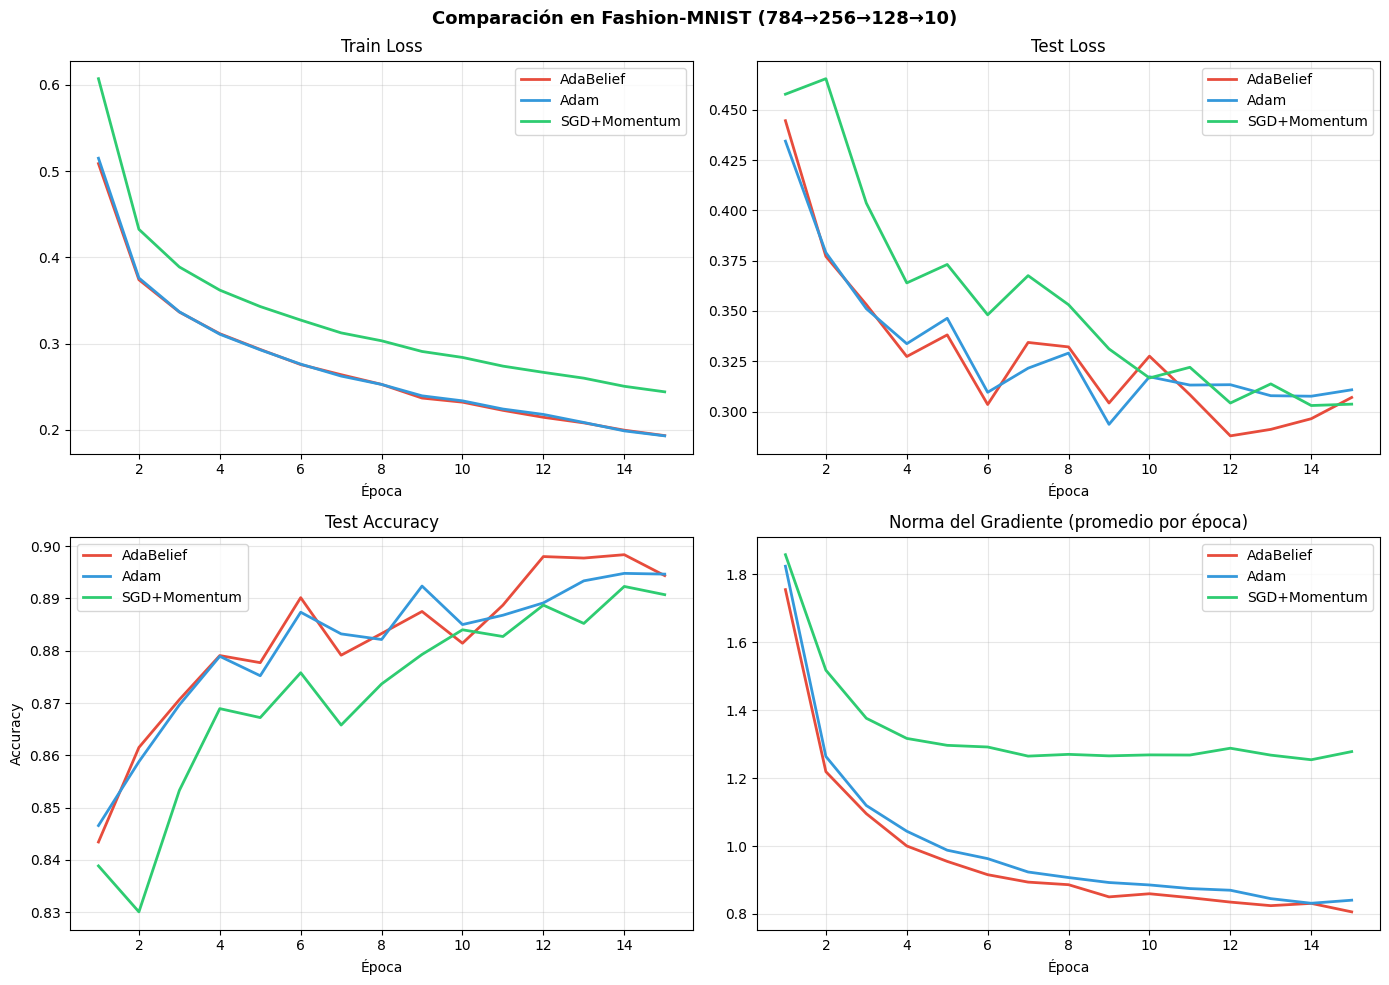


Accuracy final:
  AdaBelief      : 0.8944
  Adam           : 0.8946
  SGD+Momentum   : 0.8907


In [15]:
# ── Gráficas comparativas ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación en Fashion-MNIST (784→256→128→10)', fontsize=13, fontweight='bold')
epochs_x = range(1, EPOCHS + 1)

# Train loss
ax = axes[0, 0]
for name, h in histories.items():
    ax.plot(epochs_x, h['train_loss'], color=COLORS[name], label=name, lw=2)
ax.set_title('Train Loss'); ax.set_xlabel('Época'); ax.legend(); ax.grid(alpha=0.3)

# Test loss
ax = axes[0, 1]
for name, h in histories.items():
    ax.plot(epochs_x, h['test_loss'], color=COLORS[name], label=name, lw=2)
ax.set_title('Test Loss'); ax.set_xlabel('Época'); ax.legend(); ax.grid(alpha=0.3)

# Test accuracy
ax = axes[1, 0]
for name, h in histories.items():
    ax.plot(epochs_x, h['test_acc'], color=COLORS[name], label=name, lw=2)
ax.set_title('Test Accuracy'); ax.set_xlabel('Época'); ax.set_ylabel('Accuracy'); ax.legend(); ax.grid(alpha=0.3)

# norma del gradiente
ax = axes[1, 1]
for name, h in histories.items():
    ax.plot(epochs_x, h['grad_norm'], color=COLORS[name], label=name, lw=2)
ax.set_title('Norma del Gradiente (promedio por época)'); ax.set_xlabel('Época'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nAccuracy final:')
for name, h in histories.items():
    print(f'  {name:15s}: {h["test_acc"][-1]:.4f}')

## 6. Visualización de s_t vs v_t

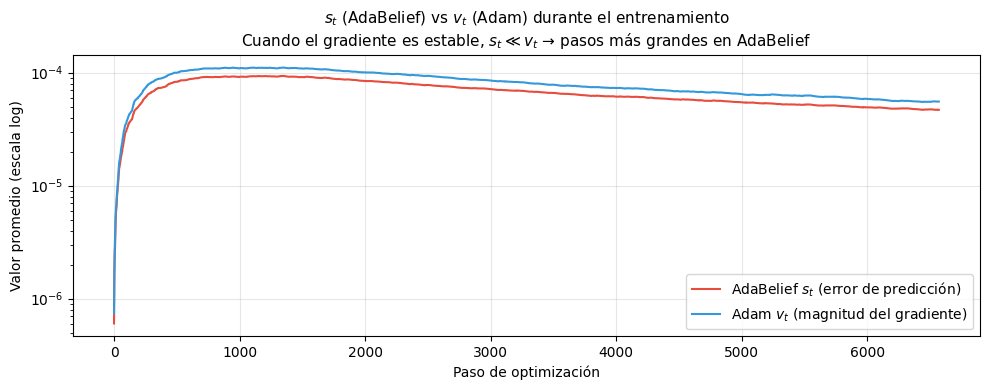

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

steps = range(len(adabelief_opt.s_t_history))
ax.plot(steps, adabelief_opt.s_t_history, color='#e74c3c', label='AdaBelief $s_t$ (error de predicción)', lw=1.5)
ax.plot(steps, adam_opt.v_t_history, color='#3498db', label='Adam $v_t$ (magnitud del gradiente)', lw=1.5)

ax.set_yscale('log')
ax.set_title('$s_t$ (AdaBelief) vs $v_t$ (Adam) durante el entrenamiento\n'
             'Cuando el gradiente es estable, $s_t \\ll v_t$ → pasos más grandes en AdaBelief',
             fontsize=11)
ax.set_xlabel('Paso de optimización')
ax.set_ylabel('Valor promedio (escala log)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Sensibilidad al Learning Rate 

In [17]:
LRS = [0.0001, 0.001, 0.005, 0.01]
LR_EPOCHS = 8

lr_results = {name: {} for name in ['AdaBelief', 'Adam', 'SGD+Momentum']}

for lr in LRS:
    print(f'\n── lr={lr} ──')
    for name, OptClass, kw in [
        ('AdaBelief', AdaBelief, {'lr': lr}),
        ('Adam', Adam, {'lr': lr}),
        ('SGD+Momentum', SGDMomentum, {'lr': lr, 'momentum': 0.9}),
    ]:
        opt = OptClass(**kw)
        _, h = train(name, opt, epochs=LR_EPOCHS)
        lr_results[name][lr] = h['test_acc'][-1]

# Tabla resumen
print('\nAccuracy final por lr:')
header = f'{"":16s}' + ''.join(f'{lr:>10}' for lr in LRS)
print(header)
for name in lr_results:
    row = f'{name:16s}' + ''.join(f'{lr_results[name][lr]:>10.4f}' for lr in LRS)
    print(row)


── lr=0.0001 ──
  [AdaBelief] Epoch  1/8 | Train Loss: 0.7130 | Test Loss: 0.4960 | Test Acc: 0.8319
  [AdaBelief] Epoch  2/8 | Train Loss: 0.4581 | Test Loss: 0.4418 | Test Acc: 0.8431
  [AdaBelief] Epoch  3/8 | Train Loss: 0.4142 | Test Loss: 0.4100 | Test Acc: 0.8544
  [AdaBelief] Epoch  4/8 | Train Loss: 0.3880 | Test Loss: 0.3878 | Test Acc: 0.8617
  [AdaBelief] Epoch  5/8 | Train Loss: 0.3698 | Test Loss: 0.3828 | Test Acc: 0.8650
  [AdaBelief] Epoch  6/8 | Train Loss: 0.3570 | Test Loss: 0.3758 | Test Acc: 0.8671
  [AdaBelief] Epoch  7/8 | Train Loss: 0.3436 | Test Loss: 0.3659 | Test Acc: 0.8693
  [AdaBelief] Epoch  8/8 | Train Loss: 0.3315 | Test Loss: 0.3515 | Test Acc: 0.8758
  [Adam] Epoch  1/8 | Train Loss: 0.7811 | Test Loss: 0.5198 | Test Acc: 0.8261
  [Adam] Epoch  2/8 | Train Loss: 0.4746 | Test Loss: 0.4518 | Test Acc: 0.8394
  [Adam] Epoch  3/8 | Train Loss: 0.4254 | Test Loss: 0.4193 | Test Acc: 0.8519
  [Adam] Epoch  4/8 | Train Loss: 0.3975 | Test Loss: 0.3961 | 

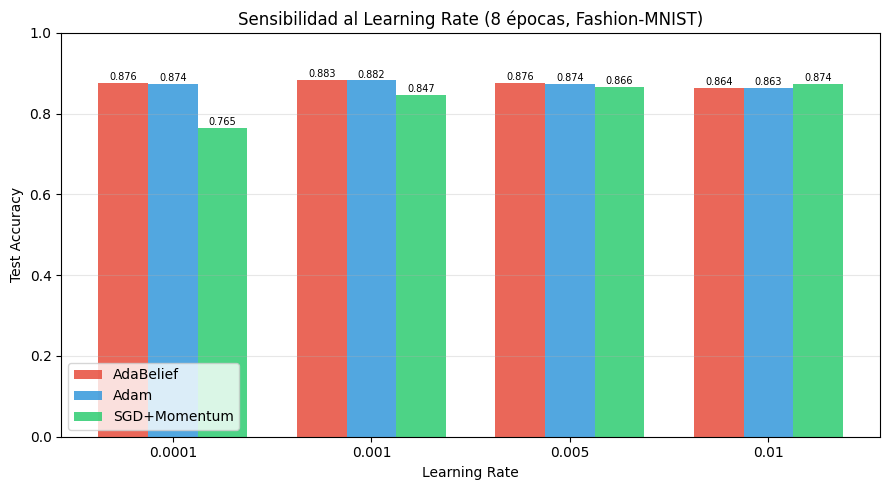

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(LRS))
width = 0.25
for i, name in enumerate(['AdaBelief', 'Adam', 'SGD+Momentum']):
    vals = [lr_results[name][lr] for lr in LRS]
    bars = ax.bar(x + i*width, vals, width, label=name, color=COLORS[name], alpha=0.85)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels([str(lr) for lr in LRS])
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Test Accuracy')
ax.set_title(f'Sensibilidad al Learning Rate ({LR_EPOCHS} épocas, Fashion-MNIST)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

## 8. Matriz de confusión

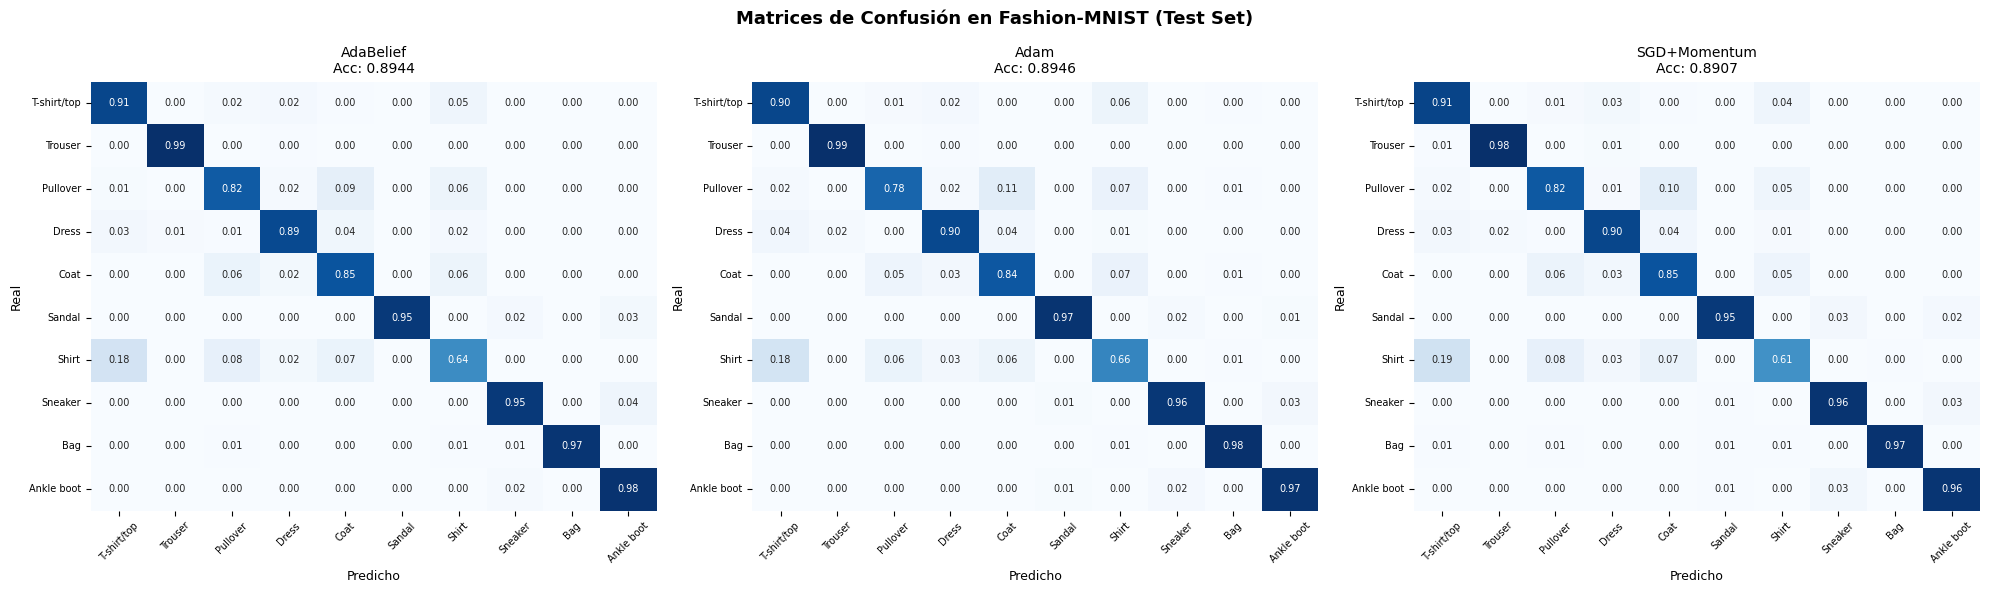

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Matrices de Confusión en Fashion-MNIST (Test Set)', fontsize=13, fontweight='bold')

for ax, name in zip(axes, ['AdaBelief', 'Adam', 'SGD+Momentum']):
    preds = models[name].predict(X_test)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_te_oh, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    # Normalizar por fila
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, annot_kws={'size': 7})
    ax.set_title(f'{name}\nAcc: {histories[name]["test_acc"][-1]:.4f}', fontsize=10)
    ax.set_xlabel('Predicho', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.show()

## 10. Visualización de predicciones en imágenes

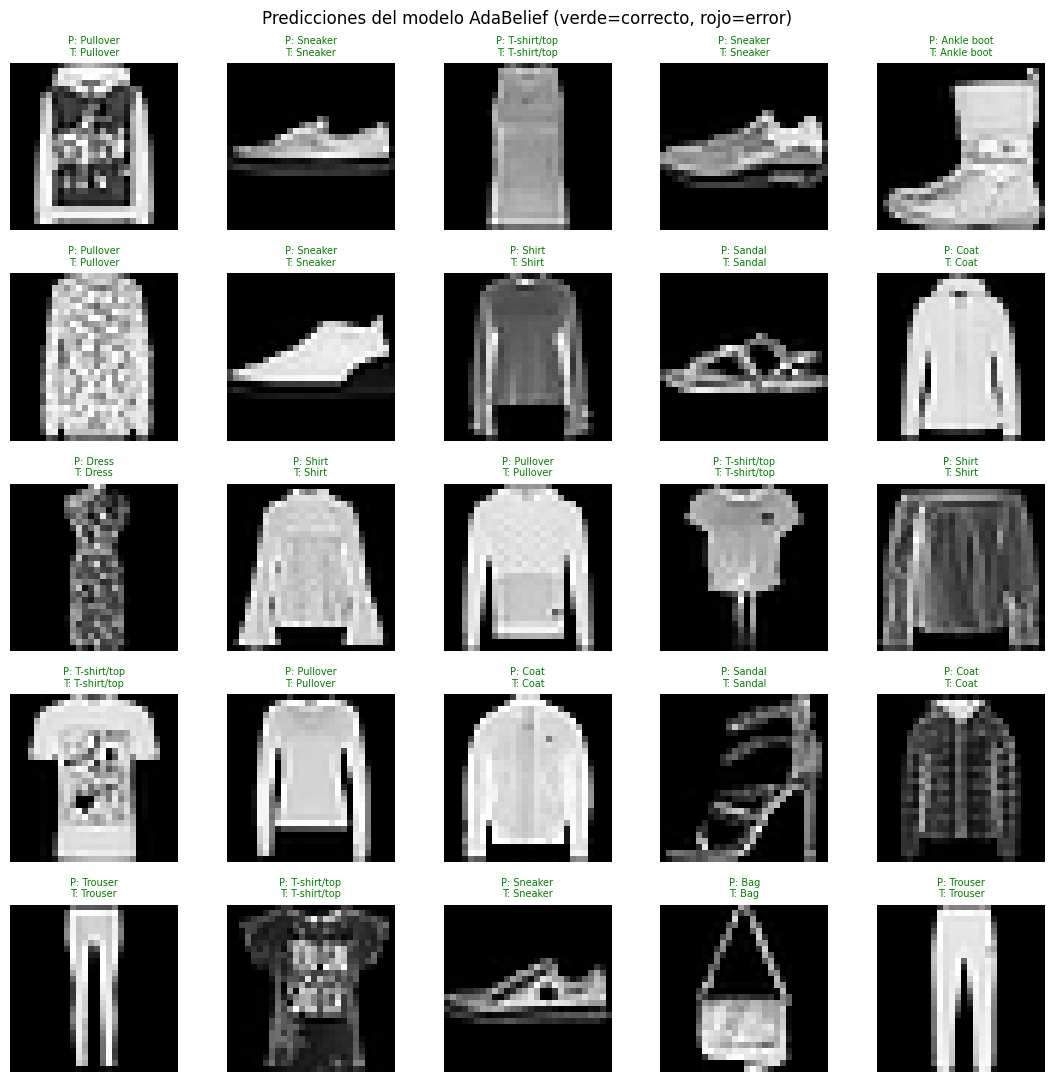

In [22]:
n_img = 25
imgs = X_test[:n_img]
y_true = np.argmax(y_te_oh[:n_img], axis=1)

fig, axes = plt.subplots(5, 5, figsize=(11, 11))
fig.suptitle('Predicciones del modelo AdaBelief (verde=correcto, rojo=error)', fontsize=12)

preds_ab = np.argmax(models['AdaBelief'].predict(imgs), axis=1)

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    color = 'green' if preds_ab[i] == y_true[i] else 'red'
    ax.set_title(f'P: {CLASS_NAMES[preds_ab[i]]}\nT: {CLASS_NAMES[y_true[i]]}',
                 color=color, fontsize=7)

plt.tight_layout()
plt.show()

## 11. Resumen

In [23]:
print('=' * 55)
print('RESUMEN FINAL — Fashion-MNIST (15 épocas)')
print('=' * 55)
print(f'{"Optimizador":20s} | {"Test Acc":>10} | {"Test Loss":>10}')
print('-' * 55)
for name in ['AdaBelief', 'Adam', 'SGD+Momentum']:
    h = histories[name]
    print(f'{name:20s} | {h["test_acc"][-1]:>10.4f} | {h["test_loss"][-1]:>10.4f}')
print('=' * 55)

RESUMEN FINAL — Fashion-MNIST (15 épocas)
Optimizador          |   Test Acc |  Test Loss
-------------------------------------------------------
AdaBelief            |     0.8944 |     0.3070
Adam                 |     0.8946 |     0.3108
SGD+Momentum         |     0.8907 |     0.3037


## 12. Digits 8×8 — Dígitos escritos a mano

Dataset de sklearn con **1,797 muestras** de dígitos 0–9 en imágenes 8×8

In [ ]:
# ── Carga y preprocesamiento ─────────────────────────────────────────────────
print('Cargando Digits 8x8...')
digits_data = load_digits()
X_dig = digits_data.data / 16.0          # normalizar a [0,1]
y_dig = digits_data.target.astype(int)

X_dig_tr, X_dig_te, y_dig_tr, y_dig_te = train_test_split(
    X_dig, y_dig, test_size=0.2, random_state=42)

enc_dig = OneHotEncoder(sparse_output=False)
y_dig_tr_oh = enc_dig.fit_transform(y_dig_tr.reshape(-1, 1))
y_dig_te_oh  = enc_dig.transform(y_dig_te.reshape(-1, 1))

DIG_NAMES = [str(i) for i in range(10)]
print(f'Train: {X_dig_tr.shape}  Test: {X_dig_te.shape}')
print(f'Clases: {DIG_NAMES}')


# ── MLP específico para Digits ────────────────────────────────────────────────
class MLPDigits:
    """Red 64→128→64→10 con ReLU y softmax."""

    def __init__(self, seed=42):
        np.random.seed(seed)
        self.W1 = np.random.randn(64,  128) * np.sqrt(2/64)
        self.b1 = np.zeros((1, 128))
        self.W2 = np.random.randn(128,  64) * np.sqrt(2/128)
        self.b2 = np.zeros((1,  64))
        self.W3 = np.random.randn(64,   10) * np.sqrt(2/64)
        self.b3 = np.zeros((1,  10))
        self.params = [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

    def forward(self, X):
        self.z1 = X  @ self.W1 + self.b1;  self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2;  self.a2 = relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        return softmax(self.z3)

    def backward(self, X, y_oh, output, bs):
        dz3 = output - y_oh
        dW3 = self.a2.T @ dz3 / bs;  db3 = dz3.sum(0, keepdims=True) / bs
        da2 = dz3 @ self.W3.T;       dz2 = da2 * relu_d(self.z2)
        dW2 = self.a1.T @ dz2 / bs;  db2 = dz2.sum(0, keepdims=True) / bs
        da1 = dz2 @ self.W2.T;       dz1 = da1 * relu_d(self.z1)
        dW1 = X.T   @ dz1 / bs;      db1 = dz1.sum(0, keepdims=True) / bs
        return [dW1, db1, dW2, db2, dW3, db3]

    def predict(self, X): return self.forward(X)


# ── Función de entrenamiento para Digits ─────────────────────────────────────
def train_digits(optimizer_name, optimizer, epochs=30, batch_size=32):
    model = MLPDigits(seed=42)
    train_losses, test_losses, test_accs, grad_norms = [], [], [], []
    n = len(X_dig_tr)

    for ep in range(epochs):
        idx = np.random.permutation(n)
        Xs, Ys = X_dig_tr[idx], y_dig_tr_oh[idx]
        ep_loss, ep_gnorm, batches = 0.0, 0.0, 0

        for i in range(0, n, batch_size):
            Xb, Yb = Xs[i:i+batch_size], Ys[i:i+batch_size]
            bs = len(Xb)
            out = model.forward(Xb)
            loss = cross_entropy(out, Yb)
            grads = model.backward(Xb, Yb, out, bs)
            gnorm = float(np.sqrt(sum(np.sum(g**2) for g in grads)))
            ep_loss  += loss;  ep_gnorm += gnorm;  batches += 1
            updated = optimizer.update(model.params, grads)
            for k in range(len(model.params)):
                model.params[k][:] = updated[k]

        train_losses.append(ep_loss / batches)
        grad_norms.append(ep_gnorm / batches)
        preds = model.predict(X_dig_te)
        test_losses.append(cross_entropy(preds, y_dig_te_oh))
        test_accs.append(acc(preds, y_dig_te_oh))

        print(f'  [{optimizer_name}] Epoch {ep+1:2d}/{epochs} | '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Test Acc:  {test_accs[-1]:.4f}')

    return model, {'train_loss': train_losses, 'test_loss': test_losses,
                   'test_acc': test_accs, 'grad_norm': grad_norms}


# ── Entrenar los tres optimizadores ──────────────────────────────────────────
DIG_EPOCHS = 30
dig_histories = {};  dig_models = {}

print('\nEntrenando AdaBelief en Digits...')
m, h = train_digits('AdaBelief', AdaBelief(lr=0.001), DIG_EPOCHS)
dig_models['AdaBelief'] = m;  dig_histories['AdaBelief'] = h

print('\nEntrenando Adam en Digits...')
m, h = train_digits('Adam', Adam(lr=0.001), DIG_EPOCHS)
dig_models['Adam'] = m;  dig_histories['Adam'] = h

print('\nEntrenando SGD+Momentum en Digits...')
m, h = train_digits('SGD+Momentum', SGDMomentum(lr=0.01, momentum=0.9), DIG_EPOCHS)
dig_models['SGD+Momentum'] = m;  dig_histories['SGD+Momentum'] = h


Cargando Digits 8x8...
Train: (1437, 64)  Test: (360, 64)
Clases: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Entrenando AdaBelief en Digits...
  [AdaBelief] Epoch  1/30 | Train Loss: 1.5973 | Test Acc:  0.8500
  [AdaBelief] Epoch  2/30 | Train Loss: 0.4883 | Test Acc:  0.9222
  [AdaBelief] Epoch  3/30 | Train Loss: 0.2481 | Test Acc:  0.9500
  [AdaBelief] Epoch  4/30 | Train Loss: 0.1775 | Test Acc:  0.9722
  [AdaBelief] Epoch  5/30 | Train Loss: 0.1397 | Test Acc:  0.9722
  [AdaBelief] Epoch  6/30 | Train Loss: 0.1065 | Test Acc:  0.9750
  [AdaBelief] Epoch  7/30 | Train Loss: 0.0880 | Test Acc:  0.9694
  [AdaBelief] Epoch  8/30 | Train Loss: 0.0737 | Test Acc:  0.9750
  [AdaBelief] Epoch  9/30 | Train Loss: 0.0636 | Test Acc:  0.9806
  [AdaBelief] Epoch 10/30 | Train Loss: 0.0521 | Test Acc:  0.9750
  [AdaBelief] Epoch 11/30 | Train Loss: 0.0466 | Test Acc:  0.9750
  [AdaBelief] Epoch 12/30 | Train Loss: 0.0378 | Test Acc:  0.9750
  [AdaBelief] Epoch 13/30 | Train Loss: 0.03

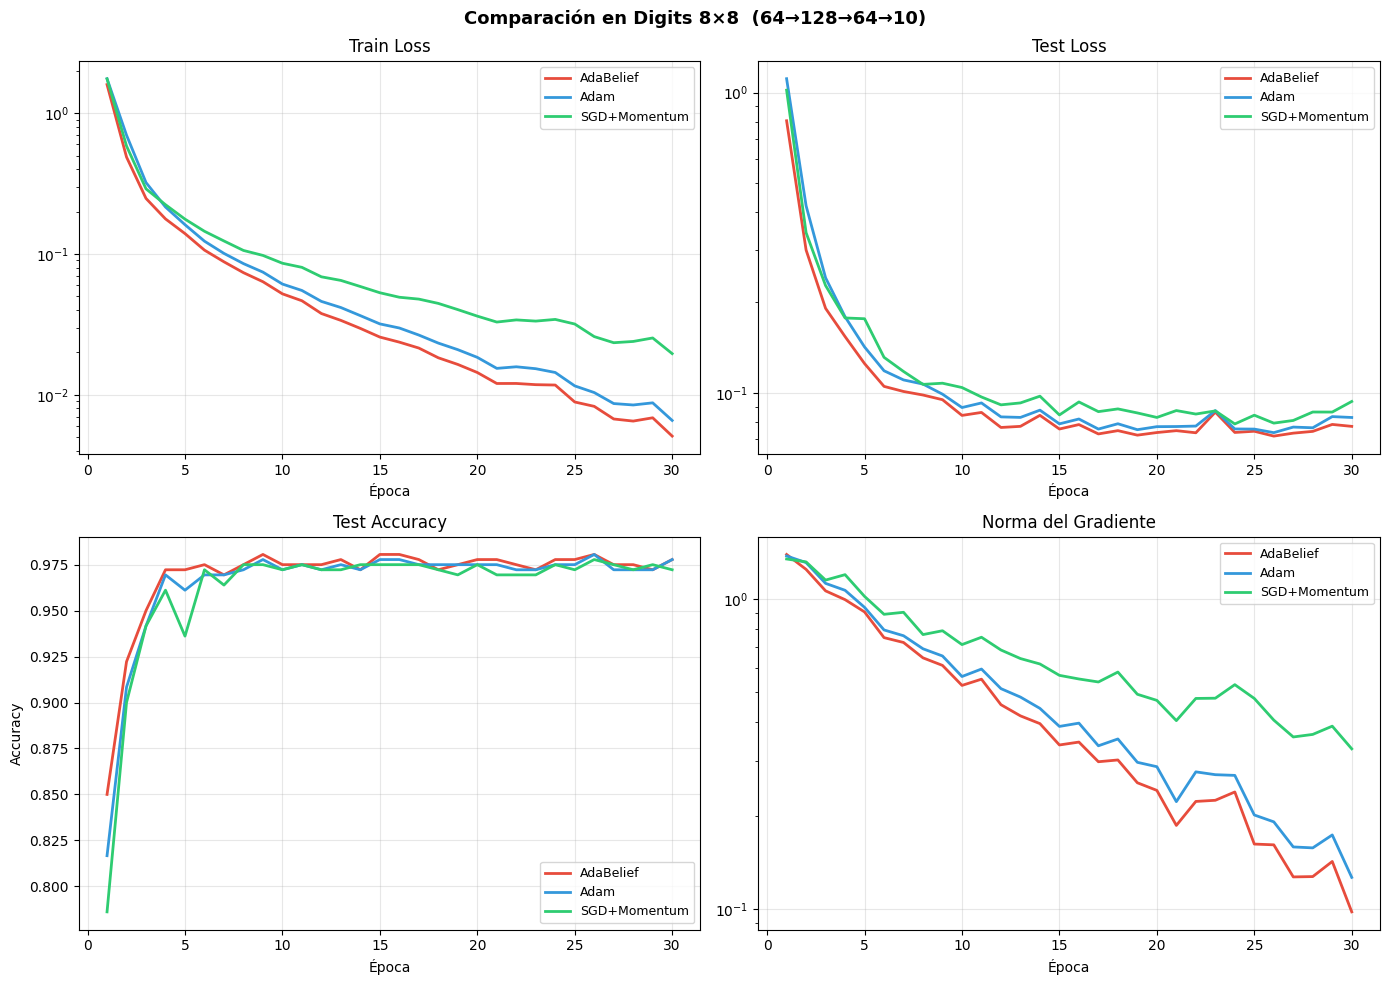


Accuracy final — Digits 8×8:
  AdaBelief      : 0.9778
  Adam           : 0.9778
  SGD+Momentum   : 0.9722


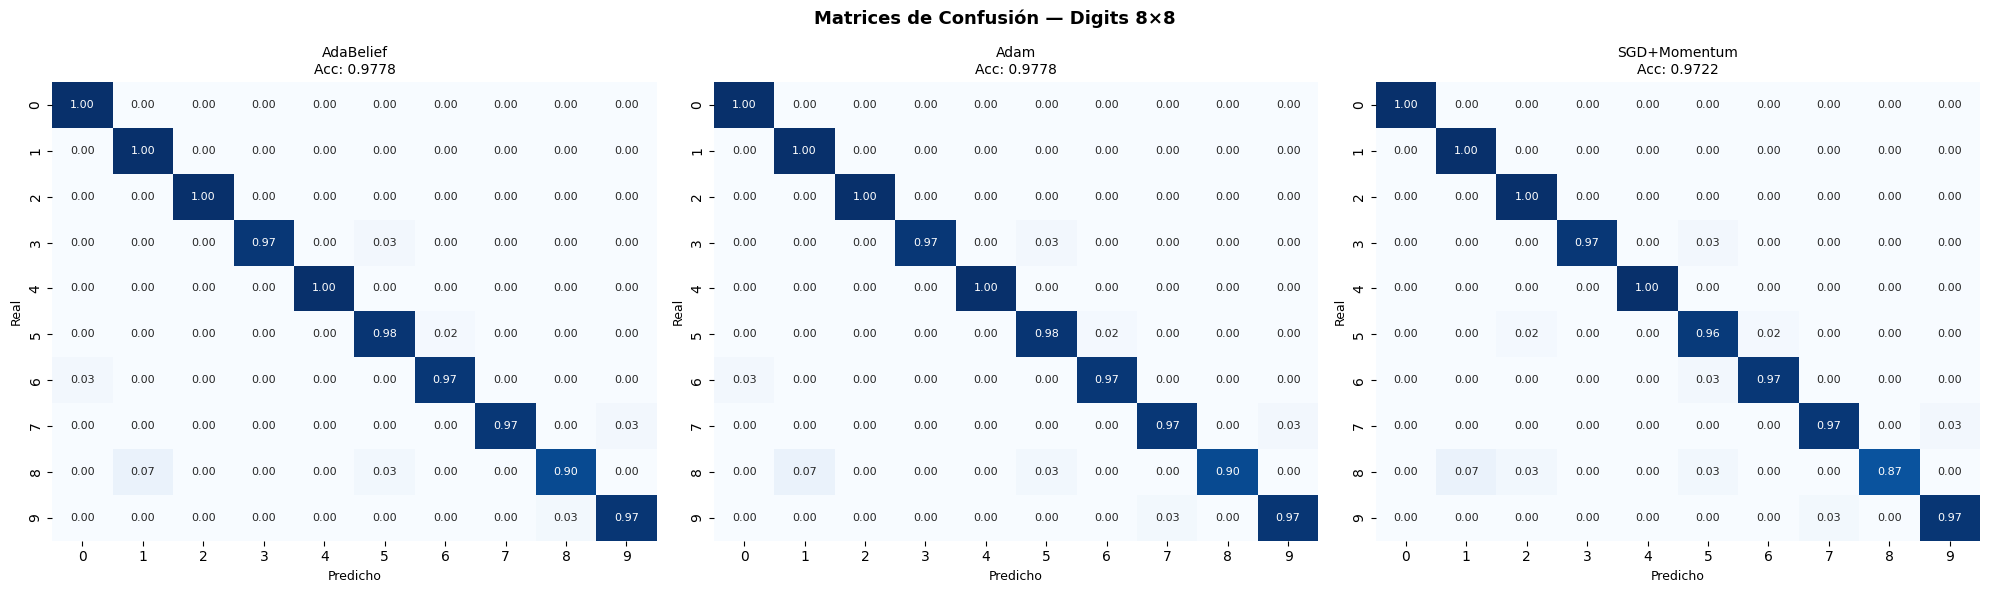

In [8]:
# ── Gráficas comparativas Digits ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación en Digits 8×8  (64→128→64→10)', fontsize=13, fontweight='bold')
epochs_x = range(1, DIG_EPOCHS + 1)

for ax, key, title in zip(
        axes.flat,
        ['train_loss', 'test_loss', 'test_acc', 'grad_norm'],
        ['Train Loss', 'Test Loss', 'Test Accuracy', 'Norma del Gradiente']):
    for name, h in dig_histories.items():
        vals = np.maximum(h[key], 1e-20)
        ax.plot(epochs_x, vals, color=COLORS[name], label=name, lw=2)
    if key in ('train_loss', 'test_loss', 'grad_norm'):
        ax.set_yscale('log')
    ax.set_title(title)
    ax.set_xlabel('Época')
    if key == 'test_acc': ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nAccuracy final — Digits 8×8:')
for name, h in dig_histories.items():
    print(f'  {name:15s}: {h["test_acc"][-1]:.4f}')


# ── Matriz de confusión Digits ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Matrices de Confusión — Digits 8×8', fontsize=13, fontweight='bold')

for ax, name in zip(axes, ['AdaBelief', 'Adam', 'SGD+Momentum']):
    preds = dig_models[name].predict(X_dig_te)
    y_pred = np.argmax(preds, axis=1)
    y_true = y_dig_te
    cm = confusion_matrix(y_true, y_pred).astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=DIG_NAMES, yticklabels=DIG_NAMES,
                ax=ax, cbar=False, annot_kws={'size': 8})
    final_acc = dig_histories[name]['test_acc'][-1]
    ax.set_title(f'{name}\nAcc: {final_acc:.4f}', fontsize=10)
    ax.set_xlabel('Predicho', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

plt.tight_layout()
plt.show()


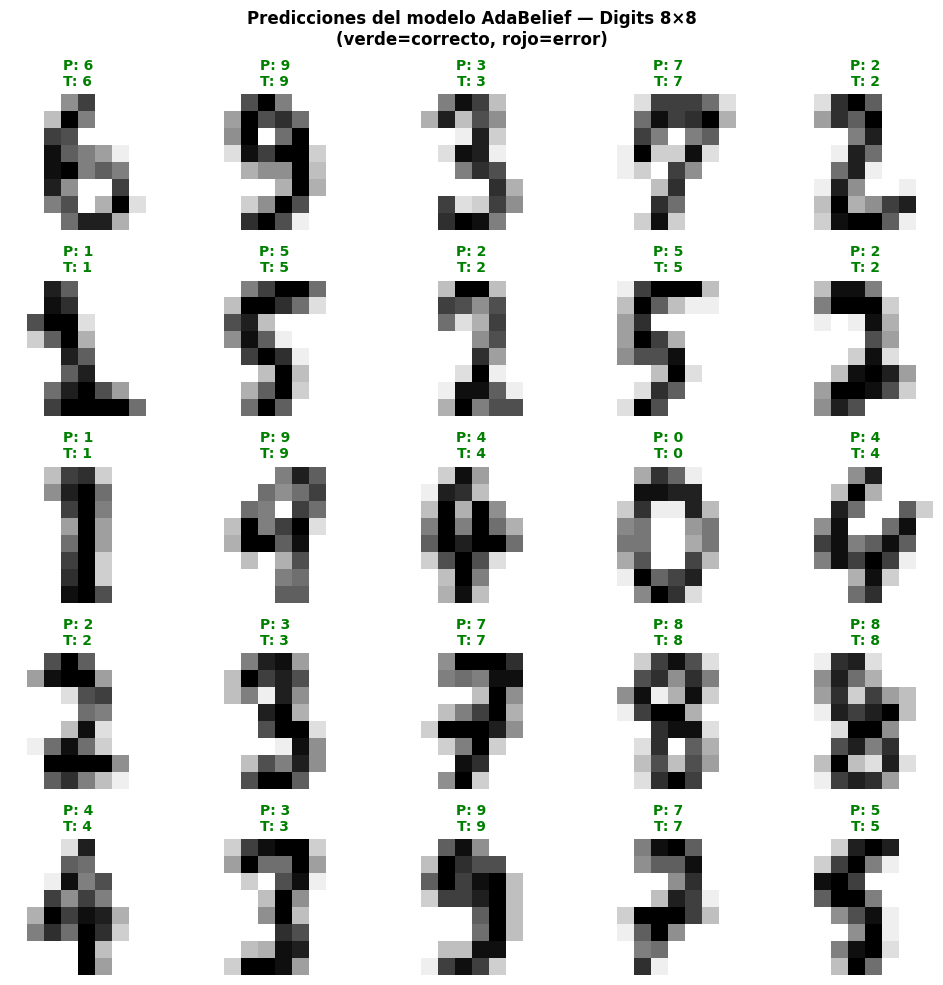

Correctas: 25/25  (100%)
Sin errores


In [28]:
# ── Visualización de predicciones — Digits 8×8 ───────────────────────────────
n_img = 25
imgs_dig  = X_dig_te[:n_img]
y_true_dig = y_dig_te[:n_img]
preds_dig  = np.argmax(dig_models['AdaBelief'].predict(imgs_dig), axis=1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('Predicciones del modelo AdaBelief — Digits 8×8\n(verde=correcto, rojo=error)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs_dig[i].reshape(8, 8), cmap='gray_r', interpolation='nearest')
    ax.axis('off')
    color = 'green' if preds_dig[i] == y_true_dig[i] else 'red'
    ax.set_title(f'P: {preds_dig[i]}\nT: {y_true_dig[i]}',
                 color=color, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Resumen de errores en las 25 muestras
n_correct = np.sum(preds_dig == y_true_dig)
print(f'Correctas: {n_correct}/25  ({n_correct/25*100:.0f}%)')
errors = [(i, y_true_dig[i], preds_dig[i]) for i in range(25) if preds_dig[i] != y_true_dig[i]]
if errors:
    print('Errores:')
    for idx, real, pred in errors:
        print(f'  Imagen {idx}: real={real}, predicho={pred}')
else:
    print('Sin errores')


## 13. Breast Cancer Wisconsin — Clasificación médica binaria

Dataset de sklearn con **569 muestras**, 30 features numéricas extraídas de biopsias de cáncer de mama.

In [ ]:
# ── Carga y preprocesamiento ─────────────────────────────────────────────────
print('Cargando Breast Cancer Wisconsin...')
bc_data = load_breast_cancer()
scaler_bc = StandardScaler()
X_bc = scaler_bc.fit_transform(bc_data.data)
y_bc = bc_data.target.astype(float)          # 0=maligno, 1=benigno

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

print(f'Train: {X_bc_tr.shape}  Test: {X_bc_te.shape}')
print(f'Clases: maligno={int((y_bc==0).sum())}  benigno={int((y_bc==1).sum())}')
print(f'Features: {bc_data.feature_names[:5].tolist()} ...')


# ── Funciones para clasificación binaria ─────────────────────────────────────
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def binary_cross_entropy(p, y):
    return -np.mean(y * np.log(p + 1e-10) + (1 - y) * np.log(1 - p + 1e-10))

def binary_acc(p, y):
    return np.mean((p.flatten() > 0.5) == y.flatten())


# ── MLP binario ───────────────────────────────────────────────────────────────
class MLPBinary:
    """Red 30→64→32→1 con ReLU ocultas y sigmoid de salida."""

    def __init__(self, seed=42):
        np.random.seed(seed)
        self.W1 = np.random.randn(30, 64) * np.sqrt(2/30)
        self.b1 = np.zeros((1, 64))
        self.W2 = np.random.randn(64, 32) * np.sqrt(2/64)
        self.b2 = np.zeros((1, 32))
        self.W3 = np.random.randn(32, 1) * np.sqrt(2/32)
        self.b3 = np.zeros((1,  1))
        self.params = [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1;   self.a1 = relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2; self.a2 = relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        return sigmoid(self.z3)

    def backward(self, X, y, output, bs):
        dz3 = output - y.reshape(-1, 1)
        dW3 = self.a2.T @ dz3 / bs; db3 = dz3.sum(0, keepdims=True) / bs
        da2 = dz3 @ self.W3.T; dz2 = da2 * relu_d(self.z2)
        dW2 = self.a1.T @ dz2 / bs; db2 = dz2.sum(0, keepdims=True) / bs
        da1 = dz2 @ self.W2.T; dz1 = da1 * relu_d(self.z1)
        dW1 = X.T   @ dz1 / bs; db1 = dz1.sum(0, keepdims=True) / bs
        return [dW1, db1, dW2, db2, dW3, db3]

    def predict(self, X): return self.forward(X)


# ── Función de entrenamiento binario ─────────────────────────────────────────
def train_bc(optimizer_name, optimizer, epochs=50, batch_size=32):
    model = MLPBinary(seed=42)
    train_losses, test_losses, test_accs, grad_norms = [], [], [], []
    n = len(X_bc_tr)

    for ep in range(epochs):
        idx = np.random.permutation(n)
        Xs, ys = X_bc_tr[idx], y_bc_tr[idx]
        ep_loss, ep_gnorm, batches = 0.0, 0.0, 0

        for i in range(0, n, batch_size):
            Xb = Xs[i:i+batch_size]
            yb = ys[i:i+batch_size]
            bs = len(Xb)
            out = model.forward(Xb)
            loss = binary_cross_entropy(out.flatten(), yb)
            grads = model.backward(Xb, yb, out, bs)
            gnorm = float(np.sqrt(sum(np.sum(g**2) for g in grads)))
            ep_loss  += loss;  ep_gnorm += gnorm;  batches += 1
            updated = optimizer.update(model.params, grads)
            for k in range(len(model.params)):
                model.params[k][:] = updated[k]

        train_losses.append(ep_loss / batches)
        grad_norms.append(ep_gnorm / batches)
        preds = model.predict(X_bc_te)
        test_losses.append(binary_cross_entropy(preds.flatten(), y_bc_te))
        test_accs.append(binary_acc(preds, y_bc_te))

        print(f'  [{optimizer_name}] Epoch {ep+1:2d}/{epochs} | '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Test Acc:  {test_accs[-1]:.4f}')

    return model, {'train_loss': train_losses, 'test_loss': test_losses,
                   'test_acc': test_accs, 'grad_norm': grad_norms}


# ── Entrenar los tres optimizadores ──────────────────────────────────────────
BC_EPOCHS = 50
bc_histories = {};  bc_models = {}

print('\nEntrenando AdaBelief en Breast Cancer...')
m, h = train_bc('AdaBelief', AdaBelief(lr=0.001), BC_EPOCHS)
bc_models['AdaBelief'] = m;  bc_histories['AdaBelief'] = h

print('\nEntrenando Adam en Breast Cancer...')
m, h = train_bc('Adam', Adam(lr=0.001), BC_EPOCHS)
bc_models['Adam'] = m;  bc_histories['Adam'] = h

print('\nEntrenando SGD+Momentum en Breast Cancer...')
m, h = train_bc('SGD+Momentum', SGDMomentum(lr=0.01, momentum=0.9), BC_EPOCHS)
bc_models['SGD+Momentum'] = m;  bc_histories['SGD+Momentum'] = h


Cargando Breast Cancer Wisconsin...
Train: (455, 30)  Test: (114, 30)
Clases: maligno=212  benigno=357
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ...

Entrenando AdaBelief en Breast Cancer...
  [AdaBelief] Epoch  1/50 | Train Loss: 0.3520 | Test Acc:  0.9123
  [AdaBelief] Epoch  2/50 | Train Loss: 0.1630 | Test Acc:  0.9386
  [AdaBelief] Epoch  3/50 | Train Loss: 0.0985 | Test Acc:  0.9474
  [AdaBelief] Epoch  4/50 | Train Loss: 0.0848 | Test Acc:  0.9474
  [AdaBelief] Epoch  5/50 | Train Loss: 0.0686 | Test Acc:  0.9474
  [AdaBelief] Epoch  6/50 | Train Loss: 0.0615 | Test Acc:  0.9474
  [AdaBelief] Epoch  7/50 | Train Loss: 0.0576 | Test Acc:  0.9561
  [AdaBelief] Epoch  8/50 | Train Loss: 0.0497 | Test Acc:  0.9561
  [AdaBelief] Epoch  9/50 | Train Loss: 0.0451 | Test Acc:  0.9561
  [AdaBelief] Epoch 10/50 | Train Loss: 0.0421 | Test Acc:  0.9649
  [AdaBelief] Epoch 11/50 | Train Loss: 0.0388 | Test Acc:  0.9561
  [AdaBelief] Epoch 12

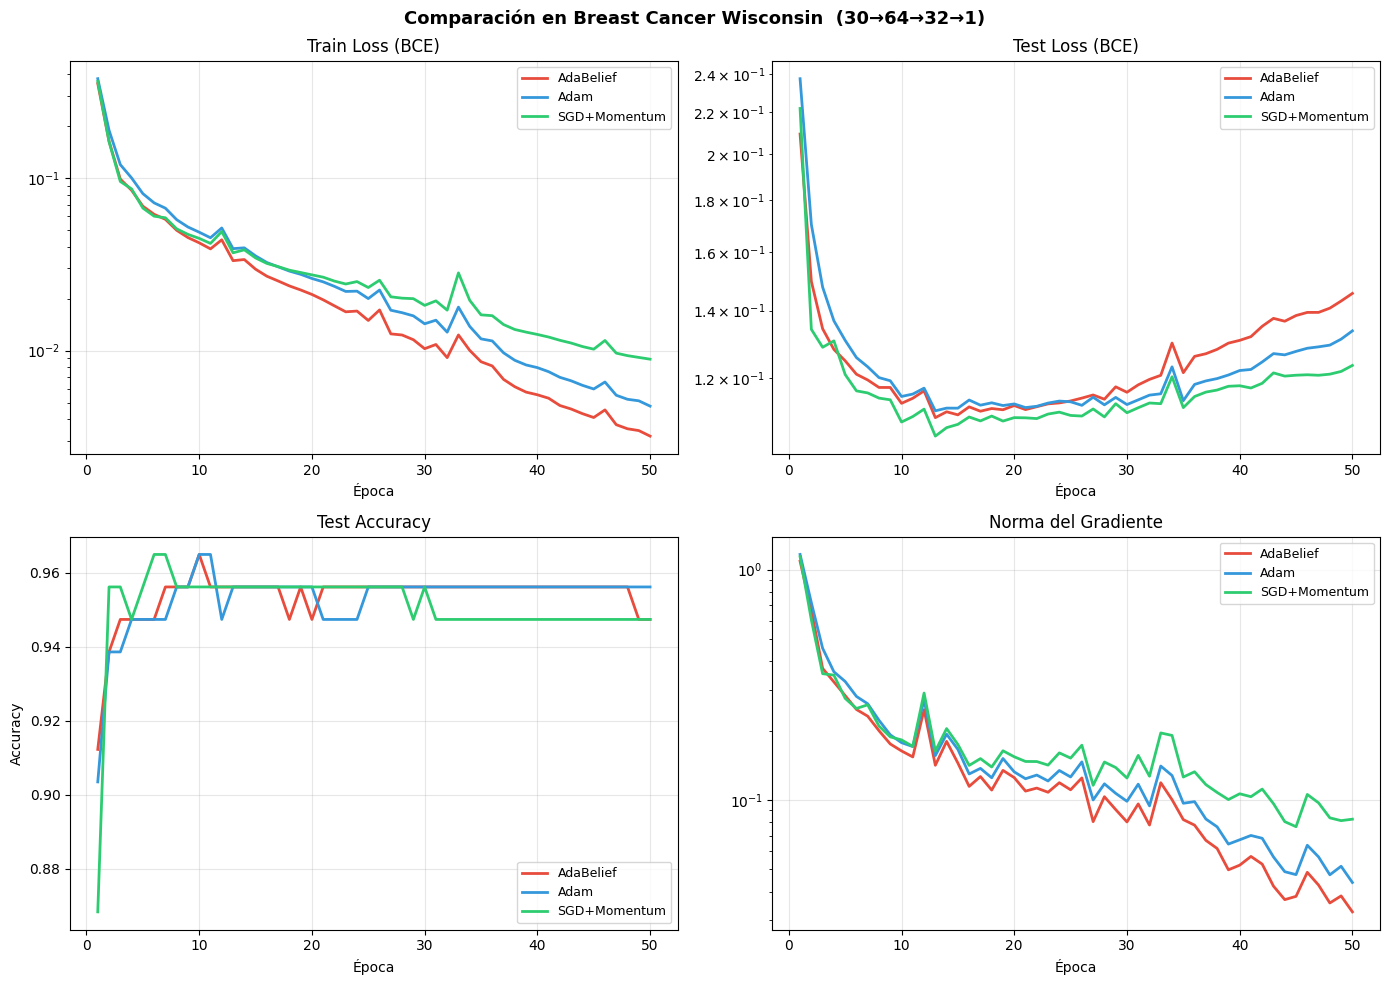


Accuracy final — Breast Cancer:
  AdaBelief      : 0.9474
  Adam           : 0.9561
  SGD+Momentum   : 0.9474

MÉTRICAS CLÍNICAS — Breast Cancer (Test Set)

AdaBelief:
  Accuracy:              0.9474
  AUC-ROC:               0.9924
  Recall maligno:        0.9762  (crítico: no perder casos malignos)
  Precisión benigno:     0.9853

Adam:
  Accuracy:              0.9474
  AUC-ROC:               0.9927
  Recall maligno:        0.9762  (crítico: no perder casos malignos)
  Precisión benigno:     0.9855

SGD+Momentum:
  Accuracy:              0.9474
  AUC-ROC:               0.9904
  Recall maligno:        0.9524  (crítico: no perder casos malignos)
  Precisión benigno:     0.9714


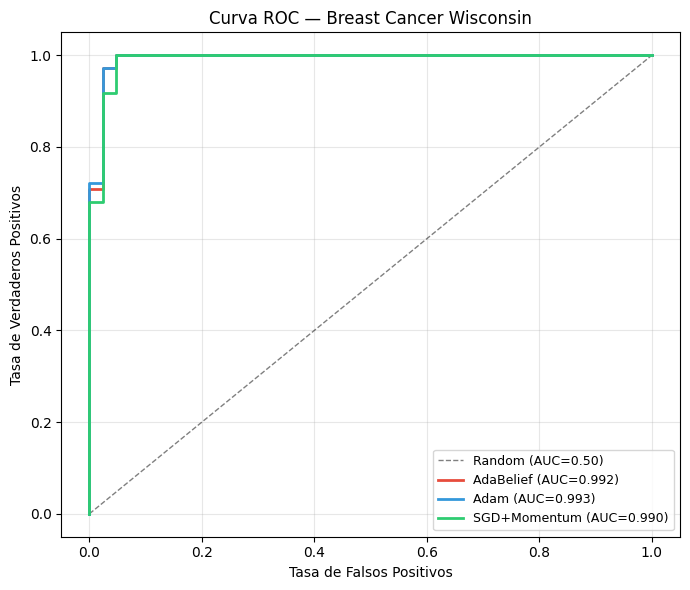

In [ ]:
# ── Gráficas comparativas Breast Cancer ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación en Breast Cancer Wisconsin  (30→64→32→1)',
             fontsize=13, fontweight='bold')
epochs_x = range(1, BC_EPOCHS + 1)

for ax, key, title in zip(
        axes.flat,
        ['train_loss', 'test_loss', 'test_acc', 'grad_norm'],
        ['Train Loss (BCE)', 'Test Loss (BCE)', 'Test Accuracy', 'Norma del Gradiente']):
    for name, h in bc_histories.items():
        vals = np.maximum(h[key], 1e-20)
        ax.plot(epochs_x, vals, color=COLORS[name], label=name, lw=2)
    if key in ('train_loss', 'test_loss', 'grad_norm'):
        ax.set_yscale('log')
    ax.set_title(title)
    ax.set_xlabel('Época')
    if key == 'test_acc': ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nAccuracy final — Breast Cancer:')
for name, h in bc_histories.items():
    print(f'  {name:15s}: {h["test_acc"][-1]:.4f}')


# ── Métricas clínicas adicionales ────────────────────────────────────────────
from sklearn.metrics import classification_report, roc_auc_score

print('\n' + '='*60)
print('MÉTRICAS CLÍNICAS — Breast Cancer (Test Set)')
print('='*60)
for name in ['AdaBelief', 'Adam', 'SGD+Momentum']:
    preds = bc_models[name].predict(X_bc_te).flatten()
    y_pred_bin = (preds > 0.5).astype(int)
    auc = roc_auc_score(y_bc_te, preds)
    report = classification_report(y_bc_te, y_pred_bin, target_names=['Maligno','Benigno'], output_dict=True)
    mal_rec  = report['Maligno']['recall']
    ben_prec = report['Benigno']['precision']
    print(f'\n{name}:')
    print(f'  Accuracy: {h["test_acc"][-1]:.4f}')
    print(f'  AUC-ROC: {auc:.4f}')
    print(f'  Recall maligno: {mal_rec:.4f}  (crítico: no perder casos malignos)')
    print(f'  Precisión benigno: {ben_prec:.4f}')


# ── Curva ROC comparativa ─────────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.50)')

for name in ['AdaBelief', 'Adam', 'SGD+Momentum']:
    preds = bc_models[name].predict(X_bc_te).flatten()
    fpr, tpr, _ = roc_curve(y_bc_te, preds)
    auc = roc_auc_score(y_bc_te, preds)
    ax.plot(fpr, tpr, color=COLORS[name], lw=2, label=f'{name} (AUC={auc:.3f})')

ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — Breast Cancer Wisconsin')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


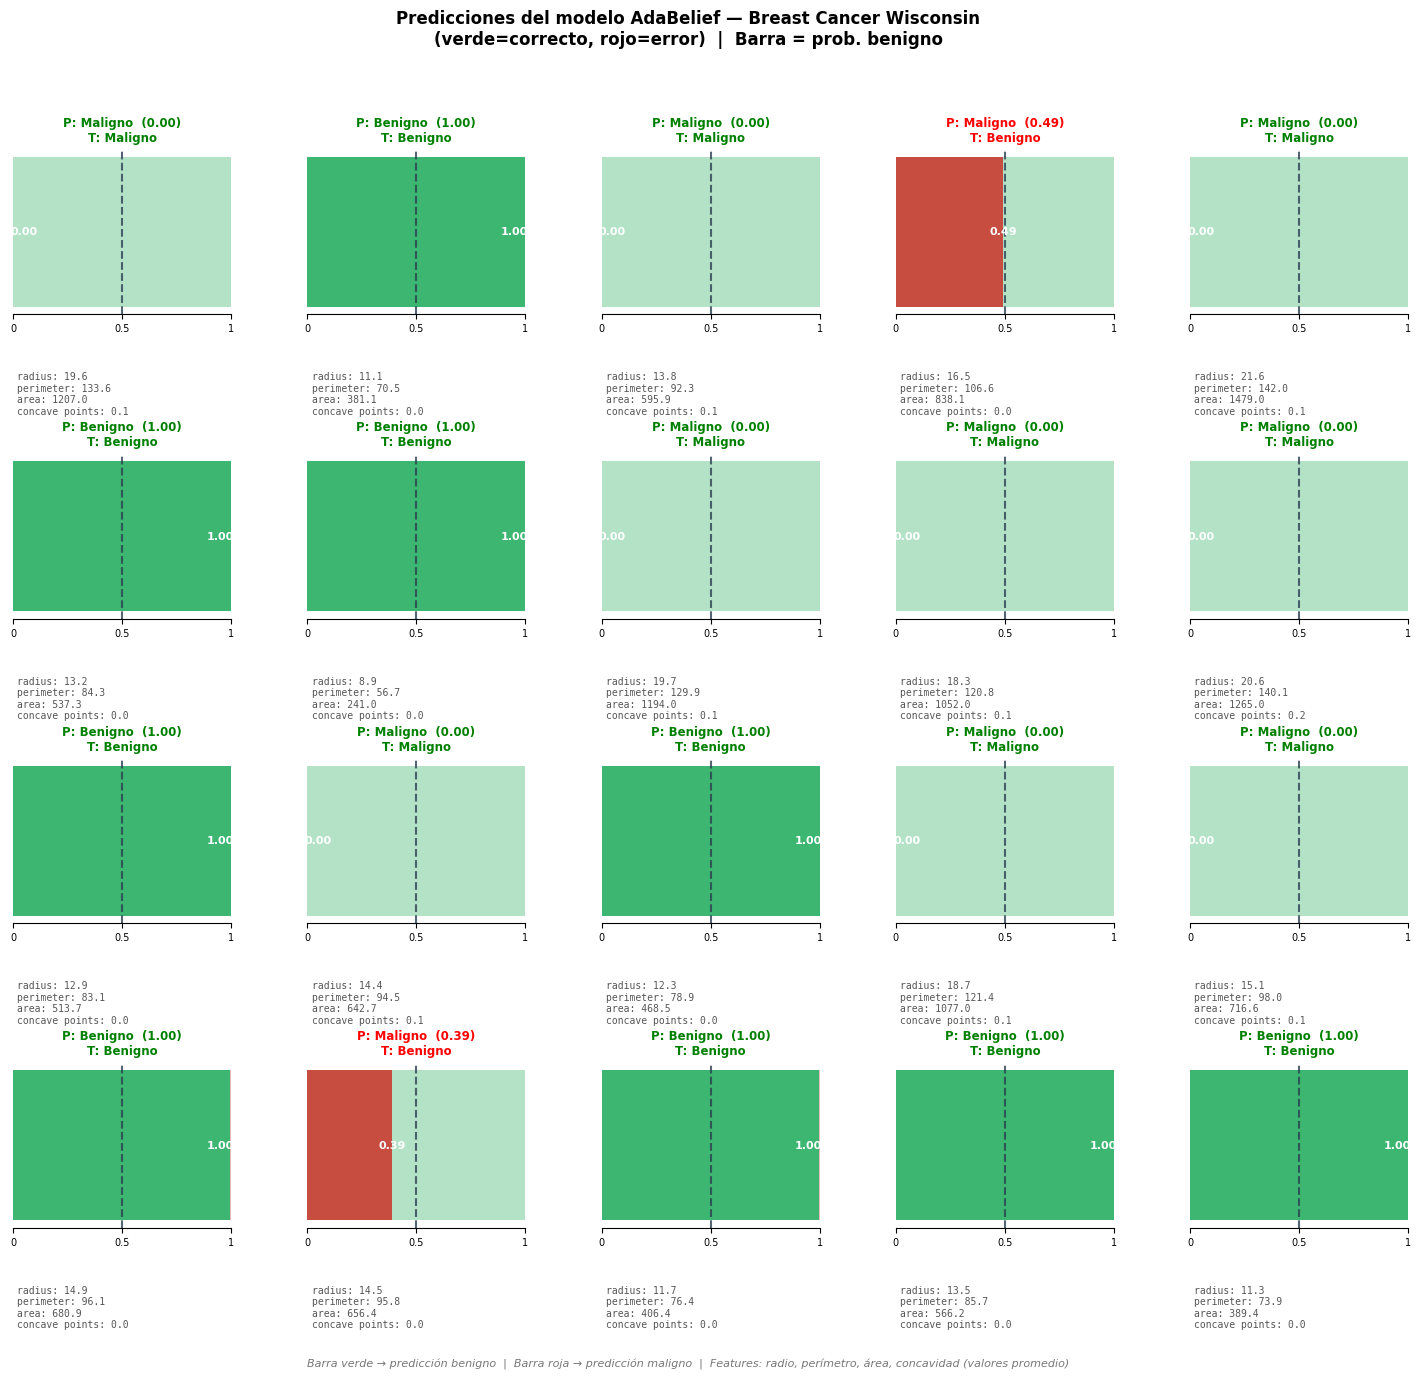

Correctas: 18/20  (90%)
Errores (críticos si real=Maligno pero predicho=Benigno):
  Paciente 3: real=Benigno, predicho=Maligno, prob=0.491
  Paciente 16: real=Benigno, predicho=Maligno, prob=0.390


In [ ]:
# ── Visualización de predicciones — Breast Cancer ────────────────────────────

from sklearn.preprocessing import StandardScaler

# Features más informativas
TOP_FEAT_IDX = [0, 2, 3, 7]   # mean radius, mean perimeter, mean area, mean concavity
TOP_FEAT_NAMES = [bc_data.feature_names[i].replace('mean ', '') for i in TOP_FEAT_IDX]
CLASS_NAMES_BC = ['Maligno', 'Benigno']

n_pac = 20   # mostrar 20 pacientes
imgs_bc   = X_bc_te[:n_pac]
y_true_bc = y_bc_te[:n_pac].astype(int)
probs_bc  = bc_models['AdaBelief'].predict(imgs_bc).flatten()
preds_bc  = (probs_bc > 0.5).astype(int)

# Recuperar valores originales (sin escalar) para mostrar
X_bc_orig = scaler_bc.inverse_transform(X_bc_te[:n_pac])

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('Predicciones del modelo AdaBelief — Breast Cancer Wisconsin\n'
             '(verde=correcto, rojo=error)  |  Barra = prob. benigno',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    correct = preds_bc[i] == y_true_bc[i]
    color   = 'green' if correct else 'red'

    # Barra horizontal de probabilidad
    prob = probs_bc[i]
    bar_color = '#27ae60' if prob > 0.5 else '#c0392b'
    complement_color = '#c0392b' if prob > 0.5 else '#27ae60'
    ax.barh([''], [prob],       color=bar_color,       alpha=0.9, height=0.6)
    ax.barh([''], [1 - prob],   left=[prob], color=complement_color, alpha=0.35, height=0.6)
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color='#2c3e50', lw=1.5, ls='--', alpha=0.8)
    # Etiqueta de probabilidad dentro de la barra
    ax.text(min(max(prob, 0.05), 0.95), 0, f'{prob:.2f}',
            ha='center', va='center', fontsize=8, fontweight='bold',
            color='white')

    # Valores de las 4 features top
    feat_str = '\n'.join([
        f'{TOP_FEAT_NAMES[j]}: {X_bc_orig[i, TOP_FEAT_IDX[j]]:.1f}'
        for j in range(4)
    ])

    ax.text(0.02, -0.35, feat_str, transform=ax.transAxes,
            fontsize=7, va='top', color='#555555',
            fontfamily='monospace')

    ax.set_title(
        f'P: {CLASS_NAMES_BC[preds_bc[i]]}  ({prob:.2f})\n'
        f'T: {CLASS_NAMES_BC[y_true_bc[i]]}',
        color=color, fontsize=8.5, fontweight='bold'
    )
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(['0', '0.5', '1'], fontsize=7)
    ax.set_yticks([])
    ax.spines[['top','right','left']].set_visible(False)

plt.subplots_adjust(hspace=0.85, wspace=0.35)
fig.text(0.5, 0.01,
         'Barra verde → predicción benigno  |  Barra roja → predicción maligno  |  '
         'Features: radio, perímetro, área, concavidad (valores promedio)',
         ha='center', fontsize=8, color='#777777', style='italic')
plt.show()

# Resumen
n_correct_bc = np.sum(preds_bc == y_true_bc)
print(f'Correctas: {n_correct_bc}/{n_pac}  ({n_correct_bc/n_pac*100:.0f}%)')
fn = [(i, y_true_bc[i], preds_bc[i], probs_bc[i])
      for i in range(n_pac) if preds_bc[i] != y_true_bc[i]]
if fn:
    print('Errores (críticos si real=Maligno pero predicho=Benigno):')
    for idx, real, pred, prob in fn:
        critico = ' FALSO NEGATIVO' if real == 0 and pred == 1 else ''
        print(f'  Paciente {idx}: real={CLASS_NAMES_BC[real]}, '
              f'predicho={CLASS_NAMES_BC[pred]}, prob={prob:.3f}{critico}')
else:
    print('Sin errores')


## 14. Resumen comparativo — tres datasets

In [25]:
print('=' * 65)
print('RESUMEN COMPARATIVO — TRES DATASETS')
print('=' * 65)
print(f'\n{"":22s} {"AdaBelief":>12} {"Adam":>12} {"SGD+Momentum":>14}')
print('-' * 65)

# Fashion-MNIST
for name, h in histories.items():
    pass  # just to get values
print(f'{"Fashion-MNIST (15 ep)":22s}', end='')
for name in ['AdaBelief', 'Adam', 'SGD+Momentum']:
    print(f'{histories[name]["test_acc"][-1]:>12.4f}', end='')
print()

# Digits
print(f'{"Digits 8x8 (30 ep)":22s}', end='')
for name in ['AdaBelief', 'Adam', 'SGD+Momentum']:
    print(f'{dig_histories[name]["test_acc"][-1]:>12.4f}', end='')
print()

# Breast Cancer
print(f'{"Breast Cancer (50 ep)":22s}', end='')
for name in ['AdaBelief', 'Adam', 'SGD+Momentum']:
    print(f'{bc_histories[name]["test_acc"][-1]:>12.4f}', end='')
print()


RESUMEN COMPARATIVO — TRES DATASETS

                          AdaBelief         Adam   SGD+Momentum
-----------------------------------------------------------------
Fashion-MNIST (15 ep)       0.8944      0.8946      0.8907
Digits 8x8 (30 ep)          0.9778      0.9778      0.9722
Breast Cancer (50 ep)       0.9474      0.9561      0.9474
